# Demand Forecasting
Predict daily, weekly, and monthly sales using traditional, machine-learning, and deep-learning approaches.


## 1. Business Problem
Forecast future sales to support inventory and demand planning.


## 2. Business Objectives
- Predict daily sales
- Summarise weekly and monthly demand
- Compare forecasting models using RMSE, MAE, and MAPE


## 3. ML Workflow
Data Preparation ? Time-Series Features ? Forecasting Models ? Evaluation ? Demand Prediction


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    from prophet import Prophet
except ImportError:
    Prophet = None

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from sklearn.preprocessing import MinMaxScaler
except ImportError:
    tf = None


## 4. Load Dataset


In [2]:
DATA_PATH = Path("../data/processed/master_df.parquet")
master_df = pd.read_parquet(DATA_PATH)
master_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_name,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44
4,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44


## 5. Dataset Overview


In [3]:
print("Dataset shape:", master_df.shape)
master_df[["order_purchase_timestamp", "payment_value"]].info()


Dataset shape: (2530433, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530433 entries, 0 to 2530432
Data columns (total 2 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   order_purchase_timestamp  datetime64[ns]
 1   payment_value             float32       
dtypes: datetime64[ns](1), float32(1)
memory usage: 29.0 MB


## 6. Data Quality Check


In [4]:
display(master_df[["order_purchase_timestamp", "payment_value"]].isna().sum().to_frame("Missing Values"))


,Missing Values
order_purchase_timestamp,0
payment_value,0


## 7. Missing Values Handling


In [5]:
demand_df = master_df[["order_purchase_timestamp", "payment_value"]].dropna().copy()
demand_df["order_purchase_timestamp"] = pd.to_datetime(demand_df["order_purchase_timestamp"])
demand_df["payment_value"] = demand_df["payment_value"].fillna(0)


## 8. Duplicate Analysis


In [6]:
print("Duplicate transaction rows:", demand_df.duplicated().sum())


Duplicate transaction rows: 1381067


## 9. Demand Definition


Daily demand is defined as total customer payment value per purchase date. The forecast target is future daily sales revenue.


## 10. Daily Sales Feature Engineering


In [7]:
daily_sales = (
    demand_df.set_index("order_purchase_timestamp")
    .resample("D")["payment_value"]
    .sum()
    .rename("Sales")
    .asfreq("D", fill_value=0)
    .to_frame()
)

daily_sales["day_of_week"] = daily_sales.index.dayofweek
daily_sales["month"] = daily_sales.index.month
for lag in [1, 7, 14]:
    daily_sales[f"lag_{lag}"] = daily_sales["Sales"].shift(lag)
daily_sales["rolling_mean_7"] = daily_sales["Sales"].shift(1).rolling(7).mean()
model_df = daily_sales.dropna().copy()
display(model_df.head())


,Sales,day_of_week,month,lag_1,lag_7,lag_14,rolling_mean_7
order_purchase_timestamp,,,,,,,
2019-01-15,402988.03125,1,1,608065.00000,316395.65625,396370.34375,654632.254464
2019-01-16,402357.03125,2,1,402988.03125,363005.34375,429127.00000,667002.593750
2019-01-17,467262.43750,3,1,402357.03125,483639.03125,447308.75000,672624.263393
2019-01-18,801163.12500,4,1,467262.43750,879621.56250,684085.87500,670284.750000
2019-01-19,852250.93750,5,1,801163.12500,882321.68750,908326.62500,659076.401786


## 11. Daily Sales Trend


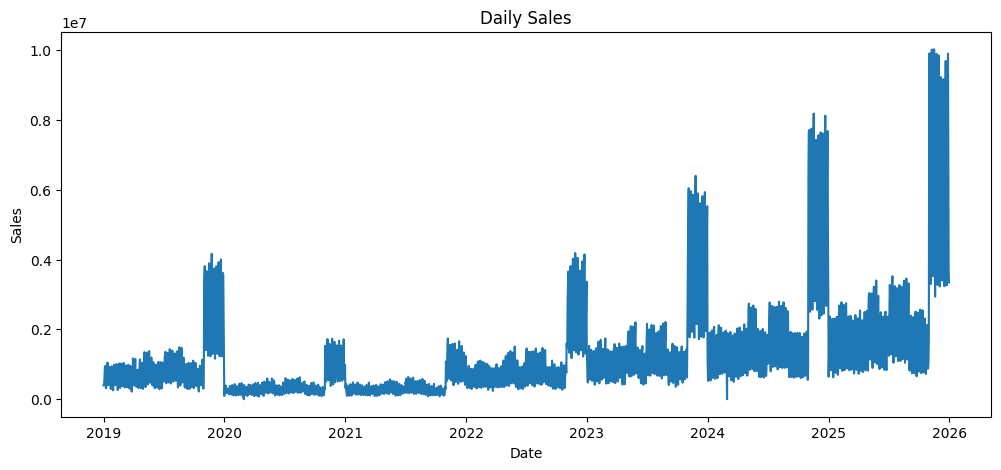

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales["Sales"])
plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


## 12. Weekly Sales


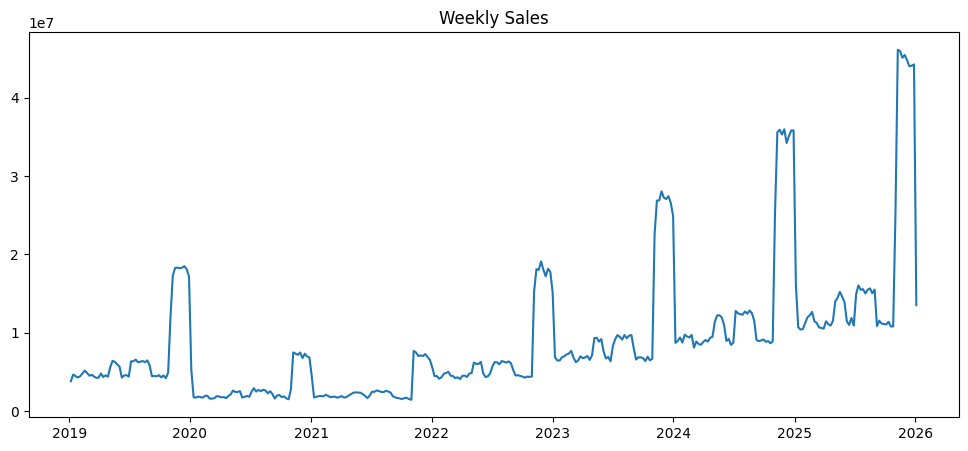

,Weekly Sales
order_purchase_timestamp,
2025-12-07,44816368.0
2025-12-14,44038784.0
2025-12-21,44111884.0
2025-12-28,44280488.0
2026-01-04,13526686.0


In [9]:
weekly_sales = daily_sales["Sales"].resample("W").sum()
plt.figure(figsize=(12, 5))
plt.plot(weekly_sales.index, weekly_sales)
plt.title("Weekly Sales")
plt.show()
display(weekly_sales.tail().to_frame("Weekly Sales"))


## 13. Monthly Sales


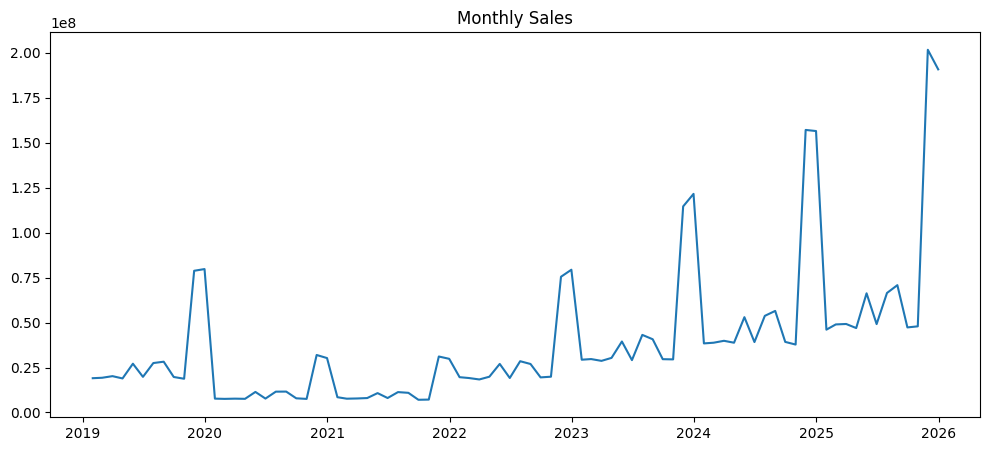

,Monthly Sales
order_purchase_timestamp,
2025-08-31,70787272.0
2025-09-30,47294664.0
2025-10-31,47894796.0
2025-11-30,201660240.0
2025-12-31,190774208.0


In [10]:
monthly_sales = daily_sales["Sales"].resample("ME").sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales)
plt.title("Monthly Sales")
plt.show()
display(monthly_sales.tail().to_frame("Monthly Sales"))


## 14. Train/Test Split


In [11]:
test_days = min(30, max(7, len(model_df) // 5))
train = model_df.iloc[:-test_days].copy()
test = model_df.iloc[-test_days:].copy()

X_train = train.drop(columns="Sales")
y_train = train["Sales"]
X_test = test.drop(columns="Sales")
y_test = test["Sales"]
print("Training days:", len(train))
print("Testing days:", len(test))


Training days: 2513
Testing days: 30


## 15. Evaluation Function


In [12]:
def evaluate_forecast(name, actual, prediction):
    prediction = np.maximum(np.asarray(prediction), 0)
    result = {
        "Model": name,
        "RMSE": mean_squared_error(actual, prediction) ** 0.5,
        "MAE": mean_absolute_error(actual, prediction),
        "MAPE": mean_absolute_percentage_error(actual, prediction) * 100
    }
    return result, prediction

forecast_results = []
forecast_predictions = {}


## 16. ARIMA


In [13]:
arima_model = ARIMA(train["Sales"], order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(steps=len(test))
result, arima_forecast = evaluate_forecast("ARIMA", y_test, arima_forecast)
forecast_results.append(result)
forecast_predictions["ARIMA"] = arima_forecast
print(result)


{'Model': 'ARIMA', 'RMSE': 3413467.7408364005, 'MAE': 2636172.3302649236, 'MAPE': 34.86483502681571}


## 17. SARIMA


In [14]:
sarima_model = SARIMAX(train["Sales"], order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit(disp=False)
sarima_forecast = sarima_model.forecast(steps=len(test))
result, sarima_forecast = evaluate_forecast("SARIMA", y_test, sarima_forecast)
forecast_results.append(result)
forecast_predictions["SARIMA"] = sarima_forecast
print(result)


{'Model': 'SARIMA', 'RMSE': 481555.30160800705, 'MAE': 347834.9988404752, 'MAPE': 5.050165391662366}


## 18. Prophet


In [15]:
if Prophet is not None:
    prophet_train = train.reset_index()[["order_purchase_timestamp", "Sales"]].rename(columns={"order_purchase_timestamp": "ds", "Sales": "y"})
    prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    prophet_model.fit(prophet_train)
    future = prophet_model.make_future_dataframe(periods=len(test), freq="D")
    prophet_forecast = prophet_model.predict(future).tail(len(test))["yhat"].values
    result, prophet_forecast = evaluate_forecast("Prophet", y_test, prophet_forecast)
    forecast_results.append(result)
    forecast_predictions["Prophet"] = prophet_forecast
    print(result)
else:
    print("Prophet is not installed; skip this cell or install prophet to run it.")


16:44:16 - cmdstanpy - INFO - Chain [1] start processing
16:44:18 - cmdstanpy - INFO - Chain [1] done processing


{'Model': 'Prophet', 'RMSE': 2683164.0475722635, 'MAE': 2092506.2874751429, 'MAPE': 28.297745481878266}


## 19. XGBoost


In [16]:
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_forecast = xgb_model.predict(X_test)
result, xgb_forecast = evaluate_forecast("XGBoost", y_test, xgb_forecast)
forecast_results.append(result)
forecast_predictions["XGBoost"] = xgb_forecast
print(result)


{'Model': 'XGBoost', 'RMSE': 320873.3809339753, 'MAE': 261381.0, 'MAPE': 4.9205441027879715}


## 20. LightGBM


In [17]:
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=42, verbosity=-1)
lgbm_model.fit(X_train, y_train)
lgbm_forecast = lgbm_model.predict(X_test)
result, lgbm_forecast = evaluate_forecast("LightGBM", y_test, lgbm_forecast)
forecast_results.append(result)
forecast_predictions["LightGBM"] = lgbm_forecast
print(result)


{'Model': 'LightGBM', 'RMSE': 318109.657239562, 'MAE': 230088.3997427993, 'MAPE': 3.6554426069485237}


## 21. LSTM


In [18]:
if tf is not None:
    scaler = MinMaxScaler()
    scaled_sales = scaler.fit_transform(daily_sales[["Sales"]]).flatten()
    window = 14
    X_seq, y_seq = [], []
    for i in range(window, len(scaled_sales)):
        X_seq.append(scaled_sales[i-window:i])
        y_seq.append(scaled_sales[i])
    X_seq, y_seq = np.array(X_seq), np.array(y_seq)
    split = len(X_seq) - len(test)
    lstm_model = Sequential([LSTM(32, input_shape=(window, 1)), Dense(1)])
    lstm_model.compile(optimizer="adam", loss="mse")
    lstm_model.fit(X_seq[:split].reshape(-1, window, 1), y_seq[:split], epochs=10, batch_size=16, verbose=0)
    lstm_forecast = scaler.inverse_transform(lstm_model.predict(X_seq[split:].reshape(-1, window, 1), verbose=0)).flatten()
    result, lstm_forecast = evaluate_forecast("LSTM", y_test, lstm_forecast)
    forecast_results.append(result)
    forecast_predictions["LSTM"] = lstm_forecast
    print(result)
else:
    print("TensorFlow is not installed; skip this cell or install tensorflow to run it.")


{'Model': 'LSTM', 'RMSE': 551517.704201778, 'MAE': 458763.84375, 'MAPE': 7.597821205854416}


## 22. Model Comparison


In [19]:
comparison = pd.DataFrame(forecast_results).sort_values("RMSE")
display(comparison)
best_model_name = comparison.iloc[0]["Model"]
print(f"Best model by RMSE: {best_model_name}")


,Model,RMSE,MAE,MAPE
4,LightGBM,3.181097e+05,2.300884e+05,3.655443
3,XGBoost,3.208734e+05,2.613810e+05,4.920544
1,SARIMA,4.815553e+05,3.478350e+05,5.050165
5,LSTM,5.515177e+05,4.587638e+05,7.597821
2,Prophet,2.683164e+06,2.092506e+06,28.297745
0,ARIMA,3.413468e+06,2.636172e+06,34.864835


Best model by RMSE: LightGBM


## 23. Forecast Plot


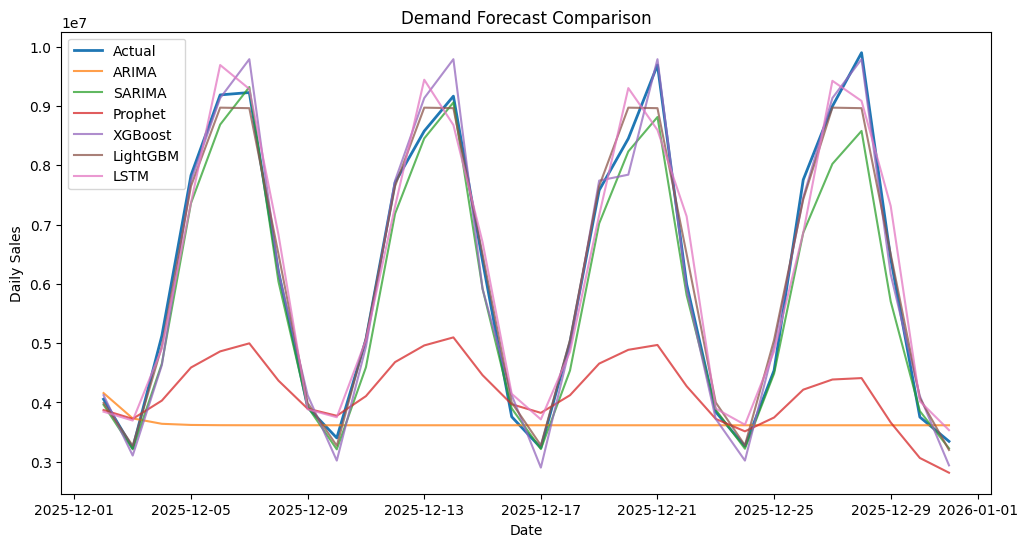

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label="Actual", linewidth=2)
for name, prediction in forecast_predictions.items():
    plt.plot(test.index, prediction, label=name, alpha=0.75)
plt.title("Demand Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.show()


## 24. Error Metrics


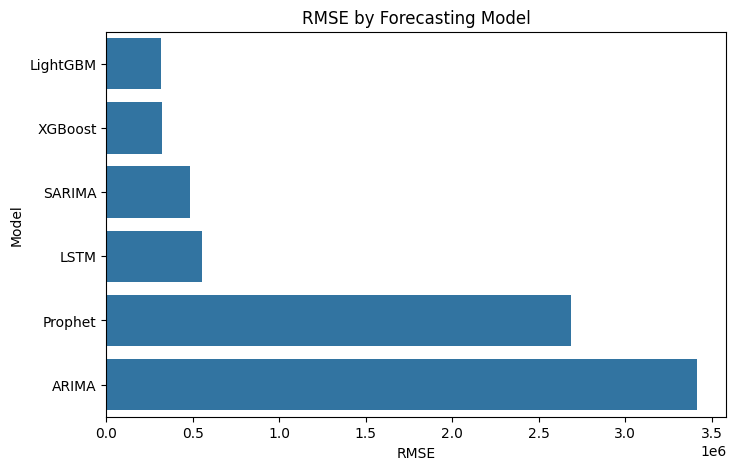

,Model,RMSE,MAE,MAPE
4,LightGBM,3.181097e+05,2.300884e+05,3.655443
3,XGBoost,3.208734e+05,2.613810e+05,4.920544
1,SARIMA,4.815553e+05,3.478350e+05,5.050165
5,LSTM,5.515177e+05,4.587638e+05,7.597821
2,Prophet,2.683164e+06,2.092506e+06,28.297745
0,ARIMA,3.413468e+06,2.636172e+06,34.864835


In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x="RMSE", y="Model")
plt.title("RMSE by Forecasting Model")
plt.show()
display(comparison[["Model", "RMSE", "MAE", "MAPE"]])


## 25. Daily Demand Prediction


In [22]:
demand_prediction = pd.DataFrame({
    "Date": test.index,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": forecast_predictions[best_model_name]
})
display(demand_prediction.tail(10))


,Date,Actual_Sales,Predicted_Sales
20,2025-12-22,5994585.00,6.501045e+06
21,2025-12-23,3839975.25,3.999466e+06
22,2025-12-24,3261210.75,3.278268e+06
23,2025-12-25,4541136.00,5.055034e+06
24,2025-12-26,7754274.50,7.423518e+06
25,2025-12-27,8993279.00,8.970101e+06
26,2025-12-28,9896027.00,8.961323e+06
27,2025-12-29,6427255.50,6.501045e+06
28,2025-12-30,3754556.75,4.073786e+06
29,2025-12-31,3344873.25,3.199430e+06


## 26. Weekly Demand Prediction


In [23]:
weekly_prediction = demand_prediction.set_index("Date").resample("W")[["Actual_Sales", "Predicted_Sales"]].sum()
display(weekly_prediction)


,Actual_Sales,Predicted_Sales
Date,,
2025-12-07,38648172.0,3.778769e+07
2025-12-14,44038784.0,4.442537e+07
2025-12-21,44111884.0,4.441274e+07
2025-12-28,44280488.0,4.418876e+07
2026-01-04,13526686.0,1.377426e+07


## 27. Monthly Demand Prediction


In [24]:
monthly_prediction = demand_prediction.set_index("Date").resample("ME")[["Actual_Sales", "Predicted_Sales"]].sum()
display(monthly_prediction)


,Actual_Sales,Predicted_Sales
Date,,
2025-12-31,184606016.0,1.845888e+08


## 28. Demand Insights


In [25]:
print(f"Selected model: {best_model_name}")
print(f"Average predicted daily demand: {demand_prediction['Predicted_Sales'].mean():.2f}")
print(f"Peak predicted daily demand: {demand_prediction['Predicted_Sales'].max():.2f}")


Selected model: LightGBM
Average predicted daily demand: 6152960.78
Peak predicted daily demand: 8970100.94


## 29. Inventory Recommendation


In [26]:
recommended_daily_stock = demand_prediction["Predicted_Sales"].mean() * 1.10
print(f"Suggested daily inventory target with 10% buffer: {recommended_daily_stock:.2f}")


Suggested daily inventory target with 10% buffer: 6768256.86


## 30. Model Export


In [29]:
from pathlib import Path
import joblib

# Create models directory
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save best model (only for tree-based models)
model_to_export = {
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}.get(best_model_name)

if model_to_export is not None:
    model_path = MODEL_DIR / "demand_forecasting_model.joblib"

    joblib.dump(model_to_export, model_path)

    print("=" * 60)
    print(f"Best Model : {best_model_name}")
    print("Model saved successfully!")
    print(f"Location : {model_path}")
    print("=" * 60)
else:
    print("=" * 60)
    print(f"Best Model : {best_model_name}")
    print("Model was not saved.")
    print("Only XGBoost and LightGBM models are exported in this workflow.")
    print("=" * 60)

Best Model : LightGBM
Model saved successfully!
Location : ..\models\demand_forecasting_model.joblib


## 31. Executive Summary


In [28]:
print("Demand forecasting workflow completed.")
print(f"Best model: {best_model_name}")
print(f"Best RMSE: {comparison.iloc[0]['RMSE']:.2f}")
print("Use daily, weekly, and monthly predictions for inventory planning.")


Demand forecasting workflow completed.
Best model: LightGBM
Best RMSE: 318109.66
Use daily, weekly, and monthly predictions for inventory planning.
